In [138]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import joblib
from src.features import get_historical_tier_diff

target_map = {0.0:0, 0.5:1, 1: 2} #0 is away win, 1 is draw, 2 is home win


In [139]:
df = pd.read_csv('../data/world_cup_training_data.csv')
df['target'] = df['target'].map(target_map) #make sure the targets are distinct ints for future purposes

squad_values = {
    "Mexico": 226, "South Korea": 154, "South Africa": 50, "Czech Republic": 200,
    "Canada": 230, "Switzerland": 360, "Qatar": 23, "Bosnia and Herzegovina": 80,
    "Brazil": 1100, "Morocco": 350, "Haiti": 10, "Scotland": 200,
    "United States": 310, "Paraguay": 100, "Australia": 40, "Turkey": 320,
    "Germany": 850, "Curaçao": 5, "Ivory Coast": 300, "Ecuador": 230,
    "Netherlands": 600, "Japan": 290, "Sweden": 210, "Tunisia": 45,
    "Belgium": 450, "Egypt": 130, "Iran": 50, "New Zealand": 20,
    "Spain": 1000, "Cape Verde": 30, "Saudi Arabia": 30, "Uruguay": 480,
    "France": 1200, "Senegal": 250, "Iraq": 10, "Norway": 450,
    "Argentina": 800, "Algeria": 180, "Austria": 240, "Jordan": 15,
    "Portugal": 1050, "DR Congo": 110, "Uzbekistan": 35, "Colombia": 280,
    "England": 1500, "Croatia": 300, "Ghana": 200, "Panama": 20
}

df['home_value'] = df['home_team'].map(lambda x: squad_values.get(x, 20))
df['away_value'] = df['away_team'].map(lambda x: squad_values.get(x, 20))


df['squad_value_diff'] = df.apply(get_historical_tier_diff, axis=1, args=(squad_values,))

#Setting up testing and training dataframes
training_set = df[df['date'] <= '2024-12-31']
test_set = df[(df['date'] > '2024-12-31') & (df['date'] < '2026-06-11')]

In [140]:
features = ['elo_diff', 'home_elo', 'away_elo', 'home_form', 'away_form', 'h2h', 'home_gd', 'away_gd', 'squad_value_diff']
X_train = training_set[features]
y = training_set['target']

z = StandardScaler()
X_scaled = z.fit_transform(X_train)
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_scaled, y)


num_neg = sum(y == 0)
num_pos = sum(y == 1)
ratio = num_neg / num_pos

# Pass it to the classifier
xgb_model = xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42)
xgb_model.fit(X_train, y)

#xgb_model = xgb.XGBClassifier()
#xgb_model.fit(X_train, y)

joblib.dump(z, 'scaler.joblib')

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:33:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


['scaler.joblib']

In [141]:
X_test = test_set[features]
y_test = test_set['target']

X_test_scaled = z.transform(X_test)

lr_preds = lr_model.predict(X_test_scaled)
xgb_preds = xgb_model.predict(X_test)

#See who is more accurate
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.2%}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.2%}")

Logistic Regression Accuracy: 59.78%
XGBoost Accuracy: 60.82%


Despite XGBoost having a higher accuracy during other attempts with XGBoost the simulations didn't go quite as planned so I will be using a LR model since it seems to be more reliable

            Feature  Coefficient  Importance_Score
0          elo_diff    -0.393612          0.393612
1          home_elo    -0.219065          0.219065
2          away_elo     0.206092          0.206092
6           home_gd    -0.175300          0.175300
7           away_gd     0.164298          0.164298
4         away_form    -0.111177          0.111177
3         home_form     0.109689          0.109689
5               h2h    -0.084989          0.084989
8  squad_value_diff    -0.035340          0.035340


<Axes: ylabel='Feature'>

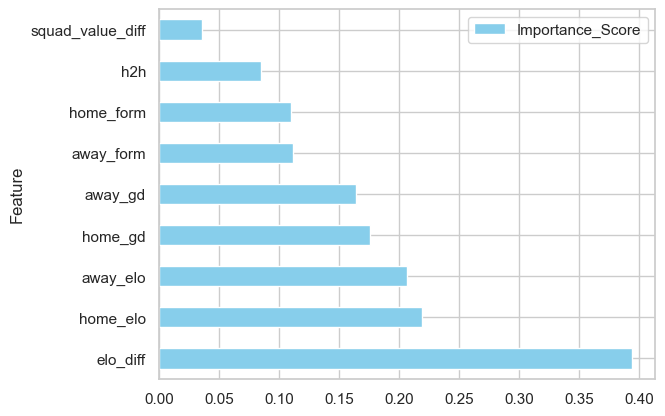

In [142]:
#Finding the MVP for LR
coefficients = lr_model.coef_[0]

importance_df = pd.DataFrame({
    'Feature': X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])],
    'Coefficient': coefficients,
    'Importance_Score': np.abs(coefficients)
}).sort_values(by='Importance_Score', ascending=False)

print(importance_df)

importance_df.plot.barh(x='Feature', y= 'Importance_Score', color='skyblue')


Model values the difference in elo as the most important factor when determining outcome

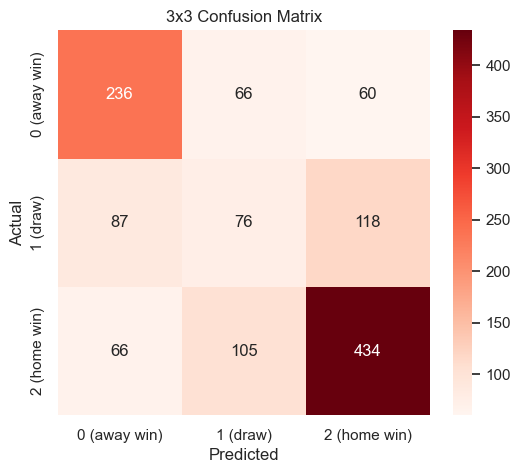

In [143]:
cm = confusion_matrix(y_test, lr_preds, labels=[0,1,2]) #Confusion matrix

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['0 (away win)', '1 (draw)', '2 (home win)'], 
            yticklabels=['0 (away win)', '1 (draw)', '2 (home win)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('3x3 Confusion Matrix')
plt.show()

In [144]:
#Find confidence threshold
probabilites = lr_model.predict_proba(X_test) #2D array containg the probability of home win, draw, and away win for each match

home, away = probabilites[:, 0], probabilites[:, 2]
diff = np.abs(home - away) #The difference between the probability of a home win vs an away win

#Get a dataframe with all the information to see at what percent_difference the model fails to predict
new = X_test.copy()

new['target'] = y_test.values
new['diff'] = diff
new['predicted'] = lr_preds    
new['success'] = (new['target'] == new['predicted']).astype(int) #Boolean to see if model predicted correctly

wrong_preds = new[new['success'] == 0] #Dataframe containing all the wrong predictions
confidence_threshold = wrong_preds['diff'].mean()

wrong_preds_draws = wrong_preds[wrong_preds['target'] == 1]
lr_draw_threshold = wrong_preds_draws['diff'].mean()

print("Draw threshold: ", lr_draw_threshold)

Draw threshold:  0.16370497450868818


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


         elo_diff     home_elo     away_elo   home_form   away_form  \
count  205.000000   205.000000   205.000000  205.000000  205.000000   
mean    21.578683  1583.198976  1561.620098    1.443415    1.354634   
std    220.769083   256.271577   252.771072    0.648315    0.595111   
min   -528.550000   881.470000   924.250000    0.000000    0.100000   
25%   -153.940000  1415.240000  1427.680000    0.900000    0.900000   
50%     48.850000  1581.220000  1557.850000    1.400000    1.300000   
75%    187.070000  1760.610000  1742.540000    2.000000    1.800000   
max    601.140000  2247.390000  2125.600000    3.000000    3.000000   

              h2h     home_gd     away_gd  squad_value_diff  target  \
count  205.000000  205.000000  205.000000        205.000000   205.0   
mean     0.496000    0.133171   -0.002439         -0.035283     1.0   
std      0.258663    1.164580    1.045928          1.281040     0.0   
min      0.000000   -3.900000   -2.700000         -4.046387     1.0   
25%  

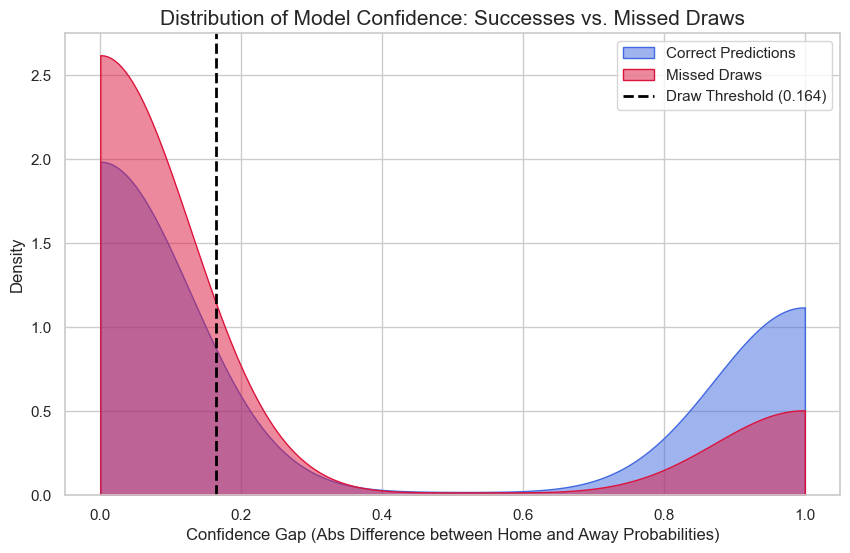

In [145]:
print(wrong_preds_draws.describe())

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.kdeplot(data=new[new['success'] == 1], x='diff', 
            fill=True, label='Correct Predictions', color='royalblue', alpha=0.5, cut = 0)

sns.kdeplot(data=wrong_preds_draws, x='diff', 
            fill=True, label='Missed Draws', color='crimson', alpha=0.5, cut = 0)

plt.axvline(x=lr_draw_threshold, color='black', linestyle='--', linewidth=2, 
            label=f'Draw Threshold ({lr_draw_threshold:.3f})')

plt.title('Distribution of Model Confidence: Successes vs. Missed Draws', fontsize=15)
plt.xlabel('Confidence Gap (Abs Difference between Home and Away Probabilities)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

plt.show()

The graph compares the distribution of the confidence gap between the correct predictions and the missed draws. due to the missed draws distribution being skewed left we can infer that that most of the missed draws occur when the model is unsure about a clear winner is essentially guessing.

The dotted line represents the draw thereshold, moving foreward if the model has a confidence rating below .16 it will predict a draw. 

In [146]:
joblib.dump(lr_model, 'world_cup_model.joblib')
joblib.dump(lr_draw_threshold, 'draw_threshold.joblib')

['draw_threshold.joblib']

In [147]:
#Make a regressor to predict goal counts
dates = pd.to_datetime(training_set['date'])
is_modern_wc = (
    ((dates.dt.year == 2006) & dates.dt.month.isin([6, 7])) |
    ((dates.dt.year == 2010) & dates.dt.month.isin([6, 7])) |
    ((dates.dt.year == 2014) & dates.dt.month.isin([6, 7])) |
    ((dates.dt.year == 2018) & dates.dt.month.isin([6, 7])) |
    ((dates.dt.year == 2022) & dates.dt.month.isin([11, 12]))
)
wc_train = training_set[is_modern_wc]
wc_test  = test_set[test_set['date'] >= '2025-01-01']  

X_train_goals = wc_train[features]
y_home_goals  = wc_train['home_score']
y_away_goals  = wc_train['away_score']

model_home_goals = xgb.XGBRegressor(objective='count:poisson', n_estimators=100)
model_away_goals = xgb.XGBRegressor(objective='count:poisson', n_estimators=100)

model_home_goals.fit(X_train_goals, y_home_goals)
model_away_goals.fit(X_train_goals, y_away_goals)

joblib.dump(model_home_goals, 'home_goals_model.joblib')
joblib.dump(model_away_goals, 'away_goals_model.joblib')

WC training samples (2006–2024): 791
Actual avg goals — home: 1.48, away: 1.20


['away_goals_model.joblib']